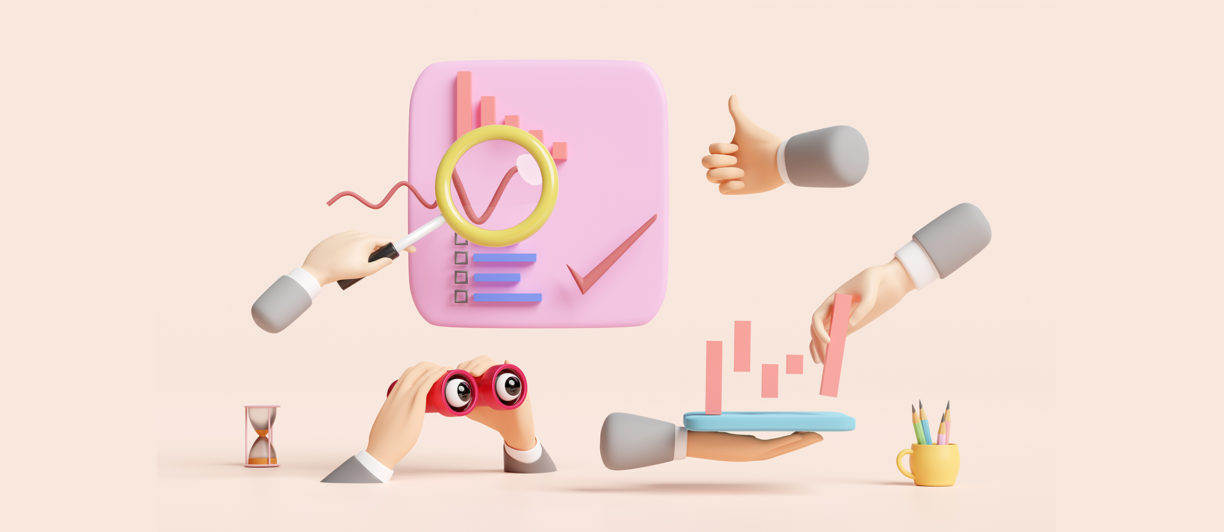

In [1]:
from IPython.display import Image, display

display(Image("ecommerce_analytics-1224x532.jpg"))

As a Data Engineer at an electronics e-commerce company, Voltmart, you have been requested by a peer Machine Learning team to clean the data containing the information about orders made last year. They are planning to further use this cleaned data to build a demand forecasting model. To achieve this, they have shared their requirements regarding the desired output table format.

An analyst shared a parquet file called `"orders_data.parquet"` for you to clean and preprocess. 

You can see the dataset schema below along with the **cleaning requirements**:

## `orders_data.parquet`

| column | data type | description | cleaning requirements | 
|--------|-----------|-------------|-----------------------|
| `order_date` | `timestamp` | Date and time when the order was made | _Modify: Remove orders placed between 12am and 5am (inclusive); convert from timestamp to date_ |
| `time_of_day` | `string` | Period of the day when the order was made | _New column containing (lower bound inclusive, upper bound exclusive): "morning" for orders placed 5-12am, "afternoon" for orders placed 12-6pm, and "evening" for 6-12pm_ |
| `order_id` | `long` | Order ID | _N/A_ |
| `product` | `string` | Name of a product ordered | _Remove rows containing "TV" as the company has stopped selling this product; ensure all values are lowercase_ |
| `product_ean` | `double` | Product ID | _N/A_ |
| `category` | `string` | Broader category of a product | _Ensure all values are lowercase_ |
| `purchase_address` | `string` | Address line where the order was made ("House Street, City, State Zipcode") | _N/A_ |
| `purchase_state` | `string` | US State of the purchase address | _New column containing: the State that the purchase was ordered from_ |
| `quantity_ordered` | `long` | Number of product units ordered | _N/A_ |
| `price_each` | `double` | Price of a product unit | _N/A_ |
| `cost_price` | `double` | Cost of production per product unit | _N/A_ |
| `turnover` | `double` | Total amount paid for a product (quantity x price) | _N/A_ |
| `margin` | `double` | Profit made by selling a product (turnover - cost) | _N/A_ |

<br>

# Voltmart Sipariş Verisi Temizleme ve Ön İşleme Projesi

Bu projede, elektronik ürünler satan e-ticaret şirketi **Voltmart** bünyesinde çalışan bir Veri Mühendisi (Data Engineer) rolü üstlenilmiştir. Makine Öğrenmesi (Machine Learning) ekibi, geçen yıla ait sipariş verilerini kullanarak bir **talep tahminleme (Demand Forecasting)** modeli geliştirmeyi planlamaktadır.

Modelin doğru ve güvenilir sonuçlar üretebilmesi için ham sipariş verilerinin temizlenmesi, standartlaştırılması ve analiz için uygun hale getirilmesi gerekmektedir. Bu amaçla analist ekibi tarafından paylaşılan **orders_data.parquet** dosyası üzerinde çeşitli veri temizleme ve dönüştürme işlemleri uygulanmıştır.

## Proje Kapsamında Yapılan İşlemler

### 1. Gece Saatlerinde Oluşturulan Siparişlerin Kaldırılması
Makine Öğrenmesi ekibinin talebi doğrultusunda, gece yarısı ile sabah 05:59 arasında oluşturulan siparişler veri setinden çıkarılmıştır.

### 2. TV Ürünlerinin Veri Setinden Çıkarılması
Şirket tarafından artık satışı yapılmayan TV ürünlerine ait sipariş kayıtları veri setinden kaldırılmıştır.

### 3. Metinsel Verilerin Standartlaştırılması
Tutarlılığı sağlamak amacıyla:

- `product` sütunu küçük harfe dönüştürülmüştür.
- `category` sütunu küçük harfe dönüştürülmüştür.

Bu sayede farklı yazım biçimlerinden kaynaklanabilecek veri kalitesi problemleri önlenmiştir.

### 4. Günün Zaman Diliminin Oluşturulması
Sipariş saatlerine göre yeni bir `time_of_day` sütunu oluşturulmuştur:

| Saat Aralığı | Değer |
|-------------|--------|
| 05:00 - 11:59 | morning |
| 12:00 - 17:59 | afternoon |
| 18:00 - 23:59 | evening |

Bu özellik, sipariş davranışlarının gün içerisindeki dağılımını analiz etmek amacıyla eklenmiştir.

### 5. Eyalet Bilgisinin Çıkarılması
`purchase_address` sütunundaki adres bilgilerinden siparişin verildiği ABD eyaleti ayrıştırılarak yeni bir `purchase_state` sütunu oluşturulmuştur.

### 6. Tarih Bilgisinin Dönüştürülmesi
`order_date` sütunundaki zaman damgası (timestamp) bilgisi yalnızca tarih bilgisini içerecek şekilde dönüştürülmüştür.

### 7. Nihai Veri Setinin Oluşturulması
Analiz ve modelleme için gerekli sütunlar seçilerek temizlenmiş son veri seti oluşturulmuştur.

### 8. Temizlenmiş Verinin Kaydedilmesi
Sonuç veri seti Parquet formatında saklanarak sonraki analiz ve makine öğrenmesi süreçlerinde kullanılmaya hazır hale getirilmiştir.

---

## Kullanılan Teknolojiler

- Apache Spark (PySpark)
- Parquet Dosya Formatı
- Data Cleaning
- Data Transformation
- Feature Engineering
- ETL (Extract, Transform, Load)

## Proje Amacı

Bu projenin amacı, ham sipariş verilerini makine öğrenmesi modellerinde kullanılabilecek kaliteli ve tutarlı bir veri setine dönüştürerek, Voltmart'ın gelecekteki ürün talebini daha doğru tahmin etmesine yardımcı olmaktır.

In [ ]:
from pyspark.sql import (
    SparkSession,
    types,
    functions as F,
)

spark = (
    SparkSession
    .builder
    .appName('cleaning_orders_dataset_with_pyspark')
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

In [4]:
# Parquet formatında saklanan sipariş verilerini Spark DataFrame'ine yükler.
# Daha sonra Spark DataFrame'ini Pandas DataFrame'ine dönüştürerek
# ilk 5 satırı görüntüler. Bu işlem, verinin doğru okunup okunmadığını
# hızlıca kontrol etmek ve veri yapısını incelemek için kullanılır.

orders_data = spark.read.parquet('orders_data.parquet')
orders_data.toPandas().head()

,order_date,order_id,product,product_id,category,purchase_address,quantity_ordered,price_each,cost_price,turnover,margin
0,2023-01-22 21:25:00,141234,iPhone,5.638009e+12,Vêtements,"944 Walnut St, Boston, MA 02215",1,700.00,231.0000,700.00,469.0000
1,2023-01-28 14:15:00,141235,Lightning Charging Cable,5.563320e+12,Alimentation,"185 Maple St, Portland, OR 97035",1,14.95,7.4750,14.95,7.4750
2,2023-01-17 13:33:00,141236,Wired Headphones,2.113973e+12,Vêtements,"538 Adams St, San Francisco, CA 94016",2,11.99,5.9950,23.98,11.9900
3,2023-01-05 20:33:00,141237,27in FHD Monitor,3.069157e+12,Sports,"738 10th St, Los Angeles, CA 90001",1,149.99,97.4935,149.99,52.4965
4,2023-01-25 11:59:00,141238,Wired Headphones,9.692681e+12,Électronique,"387 10th St, Austin, TX 73301",1,11.99,5.9950,11.99,5.9950


In [5]:
# Sipariş tarihindeki saat bilgisini kontrol eder.
# Gece 00:00 ile sabah 05:59 arasında oluşturulan siparişleri veri setinden çıkarır.
# "~" operatörü koşulun tersini alarak belirtilen saat aralığı dışındaki
# kayıtların filtrelenmesini sağlar.

orders_filtered = orders_data.filter(
    ~(
        (F.hour("order_date") >= 0) &
        (F.hour("order_date") <= 5)
    )
)

In [6]:
# Ürün adında "tv" ifadesi geçen kayıtları veri setinden çıkarır.
# lower() fonksiyonu ürün adını küçük harfe dönüştürerek
# büyük/küçük harf duyarlılığını ortadan kaldırır.
# contains("tv") ifadesi ürün adında "tv" geçen kayıtları bulur.
# "~" operatörü koşulu tersine çevirerek bu kayıtların filtrelenmesini sağlar.

orders_filtered = orders_filtered.filter(
    ~F.lower(F.col("product")).contains("tv")
)

In [7]:
# Veri tutarlılığını sağlamak amacıyla product ve category sütunlarındaki
# tüm metinleri küçük harfe dönüştürür.
# Böylece aynı değerin farklı yazımlardan (ör. "Laptop", "LAPTOP", "laptop")
# kaynaklanan tutarsızlıkları ortadan kaldırılır ve analizlerde standart bir yapı elde edilir.

orders_cleaned = (
    orders_filtered
    .withColumn("product", F.lower(F.col("product")))
    .withColumn("category", F.lower(F.col("category")))
)

In [8]:
# order_date sütunundaki saat bilgisine göre günün hangi zaman diliminde
# sipariş verildiğini belirleyen yeni bir "time_of_day" sütunu oluşturur.
# Böylece siparişler sabah, öğleden sonra ve akşam olarak kategorize edilerek
# zaman bazlı analizlerin yapılması kolaylaştırılır.

orders_cleaned = orders_cleaned.withColumn(
    "time_of_day",
    F.when((F.hour("order_date") >= 5) & (F.hour("order_date") < 12), "morning")
     .when((F.hour("order_date") >= 12) & (F.hour("order_date") < 18), "afternoon")
     .when((F.hour("order_date") >= 18) & (F.hour("order_date") < 24), "evening")
)

In [9]:
# purchase_address sütunundan eyalet (state) bilgisini çıkararak
# yeni bir "purchase_state" sütunu oluşturur.
# Adres metni önce virgüllere göre parçalanır, ardından eyalet bilgisinin
# bulunduğu bölüm seçilir ve gereksiz boşluklar temizlenir.

orders_cleaned = orders_cleaned.withColumn(
    "purchase_state",
    F.trim(
        F.split(
            F.split(F.col("purchase_address"), ",")[2],
            " "
        )[1]
    )
)

In [10]:
# order_date sütunundaki tarih-saat bilgisini yalnızca tarih formatına dönüştürür.
# Böylece saat, dakika ve saniye bilgileri kaldırılarak analizlerde
# günlük bazda çalışmak daha kolay hale gelir.

orders_cleaned = orders_cleaned.withColumn(
    "order_date",
    F.to_date("order_date")
)

In [11]:
# Analiz için gerekli sütunları seçerek nihai veri setini oluşturur.
# Veri temizleme ve dönüşüm adımlarından sonra yalnızca kullanılacak
# alanlar korunur, gereksiz sütunlar veri setinden çıkarılır.
# Böylece raporlama, analiz ve veri ambarına yükleme işlemleri için
# daha düzenli ve optimize edilmiş bir DataFrame elde edilir.

final_df = orders_cleaned.select(
    "order_date",
    "order_id",
    "product",
    "product_id",
    "category",
    "purchase_address",
    "purchase_state",
    "quantity_ordered",
    "price_each",
    "cost_price",
    "turnover",
    "margin",
    "time_of_day"
)

In [12]:
# Temizlenmiş ve dönüştürülmüş nihai veri setini Parquet formatında kaydeder.
# mode("overwrite") seçeneği, aynı isimde bir dosya veya klasör varsa
# üzerine yazarak güncellenmesini sağlar.
# Böylece analiz için hazırlanan veri kalıcı olarak saklanır ve
# sonraki süreçlerde tekrar kullanılabilir.

final_df.write.mode("overwrite").parquet("orders_data_clean.parquet")

In [13]:
clean_df = spark.read.parquet("orders_data_clean.parquet")

In [14]:
clean_df.show(10, truncate=False)

+----------+--------+--------------------------+-----------------+------------+---------------------------------------+--------------+----------------+----------+------------------+--------+--------+-----------+
|order_date|order_id|product                   |product_id       |category    |purchase_address                       |purchase_state|quantity_ordered|price_each|cost_price        |turnover|margin  |time_of_day|
+----------+--------+--------------------------+-----------------+------------+---------------------------------------+--------------+----------------+----------+------------------+--------+--------+-----------+
|2023-01-22|141234  |iphone                    |5.638008983335E12|vêtements   |944 Walnut St, Boston, MA 02215        |MA            |1               |700.0     |231.0             |700.0   |469.0   |evening    |
|2023-01-28|141235  |lightning charging cable  |5.563319511488E12|alimentation|185 Maple St, Portland, OR 97035       |OR            |1               |1